## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [1]:
# @title Ingrese datos
nombre_estudiante = "Emmanuel Alejandro Gil Leon"
carnet = 1000115165


## 1) Descripción del problema **[1 pts]**

Un vivero está analizando el crecimiento de la producción de nuevas plantas a partir de un proceso de reproducción controlada.

Se ha observado que el número de nuevas plantas producidas en el mes `n` sigue este comportamiento:

- En el mes `0` se produjeron `0` nuevas plantas.
- En el mes `1` se produjo `1` nueva planta.
- A partir del mes `2`, el número de nuevas plantas producidas es igual a la suma de las plantas producidas durante los dos meses anteriores.

### Relación de recurrencia

\[
T(n)=
\begin{cases}
0, & n=0\\
1, & n=1\\
T(n-1)+T(n-2), & n\geq2
\end{cases}
\]
Por lo tanto, la secuencia de producción es:

`0, 1, 1, 2, 3, 5, 8, 13, 21, 34, ...`

El objetivo es implementar una solución recursiva con **memoización**, de manera que los resultados ya calculados sean almacenados y reutilizados en consultas posteriores.


## 2) Requerimientos **[2 pts]**
### Requerimientos funcionales

**RF01. Ingresar el mes:**  
El sistema debe permitir recibir un número entero `n` que represente el mes que se desea consultar.

**RF02. Validar el mes:**  
El sistema debe verificar que `n` sea un número entero no negativo.

**RF03. Calcular la producción:**  
El sistema debe calcular la cantidad de nuevas plantas producidas en el mes `n` de acuerdo con la relación de recurrencia establecida.

**RF04. Aplicar memoización:**  
El sistema debe almacenar los resultados calculados para evitar repetir cálculos.

**RF05. Mostrar resultados:**  
El sistema debe mostrar la cantidad de nuevas plantas producidas para el mes consultado.

### Requerimientos no funcionales

**RNF01. Eficiencia:**  
La solución debe utilizar memoización para reducir la complejidad temporal a `O(n)`.

**RNF02. Correctitud:**  
La función debe producir los valores correspondientes a la relación de recurrencia definida.

**RNF03. Validación:**  
Las entradas inválidas deben generar un mensaje de error apropiado.

**RNF04. Legibilidad:**  
El código debe estar organizado y utilizar nombres de variables descriptivos.


## 3) Historias de usuario **[2 pts]**

### HU01 – Consultar producción de un mes

**Como** encargado del vivero,  
**quiero** consultar la cantidad de nuevas plantas producidas en un mes `n`,  
**para** conocer la producción esperada.

**Criterios de aceptación:**
- **CA01:** Si `n = 0`, el sistema debe retornar `0`.
- **CA02:** Si `n = 1`, el sistema debe retornar `1`.
- **CA03:** Si `n >= 2`, debe aplicar la recurrencia indicada.

### HU02 – Validar el mes ingresado

**Como** usuario del sistema,  
**quiero** que el mes ingresado sea validado,  
**para** evitar resultados incorrectos.

**Criterios de aceptación:**
- **CA01:** Se deben aceptar únicamente enteros no negativos.
- **CA02:** Un número negativo debe generar un `ValueError`.
- **CA03:** Un valor que no sea entero debe generar un `TypeError`.

### HU03 – Reutilizar resultados calculados

**Como** analista del vivero,
**quiero** reutilizar resultados previamente calculados,  
**para** evitar cálculos repetidos y mejorar el rendimiento.

**Criterios de aceptación:**
- **CA01:** Los resultados calculados deben almacenarse en `memo`.
- **CA02:** Si un valor ya existe en `memo`, debe reutilizarse.
- **CA03:** Una consulta posterior debe poder utilizar los valores almacenados.

### HU04 – Consultar varios meses
 
**Como** encargado del vivero,
**quiero** consultar la producción de diferentes meses,
**para** analizar cómo evoluciona la cantidad de nuevas plantas.
 
***Criterios de aceptación:*** 
 
- **CA01:** El sistema debe permitir consultar cualquier mes entero no negativo.
- **CA02:** Cada mes debe mostrar su cantidad correspondiente de nuevas plantas.
- **CA03:** Los resultados deben respetar la recurrencia definida.
 
### HU05 – Consultar meses consecutivos ###
 
**Como** encargado del vivero,
**quiero** visualizar la producción de varios meses consecutivos,
**para** observar el crecimiento de la producción.
 
***Criterios de aceptación:***
 
- **CA01:** El sistema debe generar los valores desde el mes 0 hasta el mes indicado.
- **CA02:** Los valores deben calcularse correctamente.
- **CA03:** Los resultados deben poder almacenarse para evitar cálculos repetidos.


## 4) Diagramas de flujo **[5 pts]**
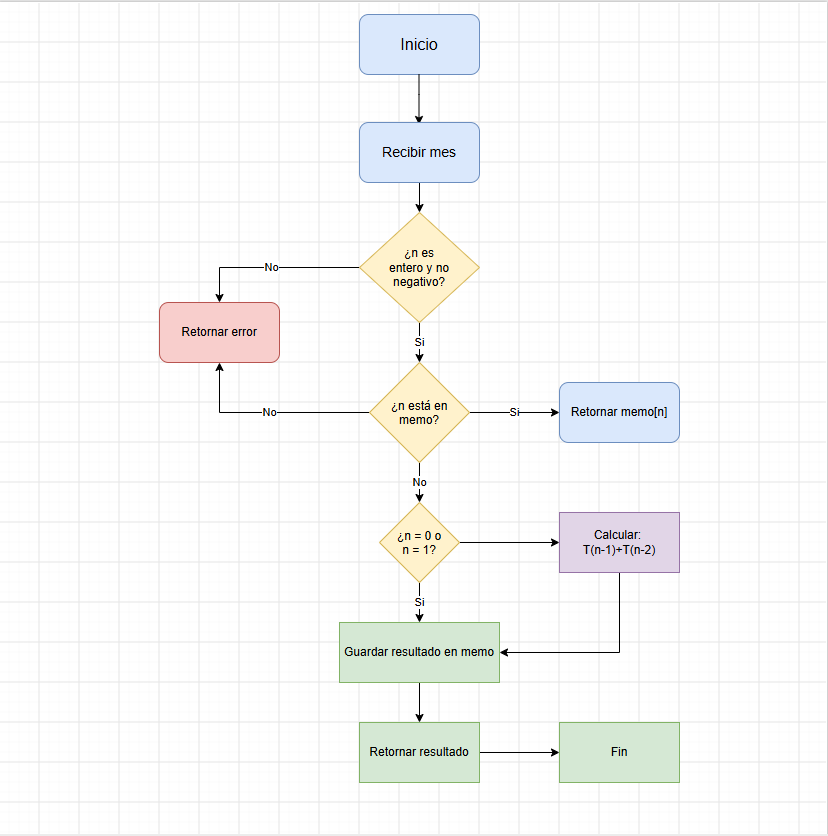
### Descripción del diagrama

1. Se recibe el mes `n`.
2. Se valida que `n` sea un entero no negativo.
3. Se revisa si el resultado ya está almacenado en `memo`.
4. Si existe, se retorna inmediatamente.
5. Si no existe, se revisan los casos base `n = 0` y `n = 1`.
6. Para `n >= 2`, se calculan `T(n-1)` y `T(n-2)`.
7. El resultado se almacena en `memo`.
8. Finalmente se retorna el número de nuevas plantas.

### 5) Análisis de complejidad **[15 pts]**
Incluye:
- Justificación
- Función T[n]
- Mejor y peor caso con gráfica


Se utiliza memoización porque la relación de recurrencia del problema calcula varias veces los mismos meses. Al almacenar en un diccionario los resultados que ya fueron calculados, estos pueden reutilizarse sin volver a ejecutar las mismas llamadas recursivas.
 
Esto permite reducir la complejidad temporal del algoritmo de aproximadamente O(2ⁿ), en el caso sin memoización, a O(n) con memoización. Además, el mejor caso ocurre cuando n = 0 o n = 1, ya que el resultado se obtiene directamente y tiene complejidad O(1).
 
- la memoización hace que el cálculo de la producción sea más eficiente y evita trabajo repetido, especialmente cuando se consultan meses grandes.

#### Solución sin memoización

La función recursiva directa sería:

$$
T(n) = T(n-1) + T(n-2)
$$

Sin memoización, los mismos subproblemas se calculan varias veces. Por ejemplo:

```text
T(5)
├── T(4)
│   ├── T(3)
│   │   ├── T(2)
│   │   └── T(1)
│   └── T(2)
│       ├── T(1)
│       └── T(0)
└── T(3)
    ├── T(2)
    │   ├── T(1)
    │   └── T(0)
    └── T(1)
```

Por esta repetición, la complejidad temporal de la solución sin memoización es aproximadamente:

$$
O(2^n)
$$
#### Solución con memoización

Con memoización, cada estado `T(k)` se calcula una sola vez y después se reutiliza.

Los estados calculados son:


$$
T(0),T(1),T(2),...,T(n)
$$

Por tanto:

- **Tiempo:** `O(n)`
- **Espacio:** `O(n)` por el diccionario `memo` y la profundidad de la recursión.

#### Función de recurrencia para el análisis

Para el número de operaciones con memoización:

$$C(n)=C(n-1)+O(1)$$

por lo que:

$$C(n)=O(n)$$

#### Mejor y peor caso

- **Mejor caso:** `n = 0` o `n = 1`. Se retorna inmediatamente: `O(1)`.
- **Peor caso:** `n` es un entero grande y no se encuentra previamente almacenado. Se calculan todos los estados hasta `n`: `O(n)`.

La memoización transforma el crecimiento exponencial de la solución ingenua en un crecimiento lineal.


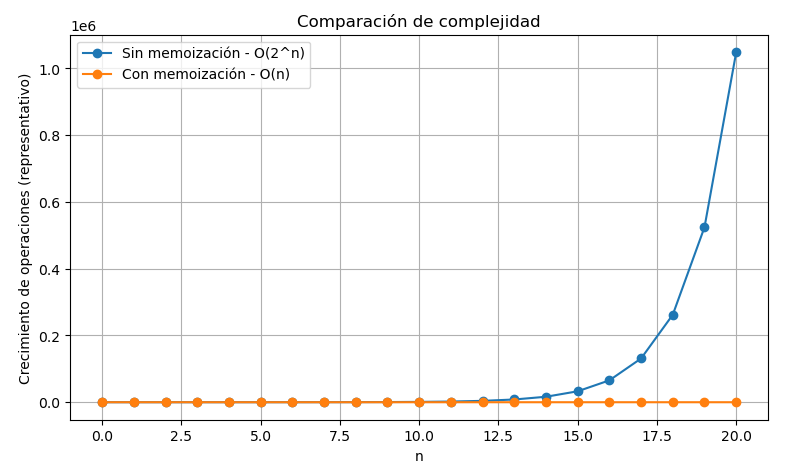



## 6) Código funcional **[15 pts]**
La siguiente función implementa la relación de recurrencia utilizando un diccionario para almacenar los resultados previamente calculados.

Se incluyen validaciones para evitar valores negativos, tipos incorrectos y valores booleanos, ya que en Python bool es una subclase de int.


In [6]:
def plantas(n, memo=None):
    """
    Calcula la cantidad de nuevas plantas producidas
    en el mes n usando recursividad y memoización.
 
    T(0) = 0
    T(1) = 1
    T(n) = T(n-1) + T(n-2)
    """
 
    # Validación de la entrada
    if not isinstance(n, int) or isinstance(n, bool):
        raise TypeError("n debe ser un entero no negativo.")
 
    if n < 0:
        raise ValueError("n debe ser un entero no negativo.")
 
    # Inicializar memo
    if memo is None:
        memo = {
            0: 0,
            1: 1
        }
 
    # Si ya tenemos el resultado, lo reutilizamos
    if n in memo:
        return memo[n]
 
    # Aplicar la recurrencia
    memo[n] = (
        plantas(n - 1, memo)
        + plantas(n - 2, memo)
    )
 
    return memo[n]
 
 
def main():
    """
    Función principal del programa.
    """
    print("   PRODUCCIÓN DE PLANTAS - VIVERO")
 
    try:
        n = int(input("Ingrese el número del mes: "))
 
        resultado = plantas(n)
 
        print()
        print("Mes:", n)
        print("Nuevas plantas producidas:", resultado)
 
    except ValueError:
        print("Error: debe ingresar un entero no negativo.")
 
    except TypeError as error:
        print("Error:", error)
 
 
if __name__ == "__main__":
    main()

   PRODUCCIÓN DE PLANTAS - VIVERO


Ingrese el número del mes:  10



Mes: 10
Nuevas plantas producidas: 55


## 7) Tests aplicados **[15 pts]**
Se comprueban:

- Casos base.
- Valores conocidos de la recurrencia.
- Entradas negativas.
- Tipos de datos incorrectos.
- Valores booleanos.


In [ ]:
def test_casos_base():
    assert plantas(0) == 0
    assert plantas(1) == 1
 
 
def test_casos_conocidos():
    assert plantas(2) == 1
    assert plantas(3) == 2
    assert plantas(4) == 3
    assert plantas(5) == 5
    assert plantas(6) == 8
    assert plantas(7) == 13
    assert plantas(8) == 21
    assert plantas(9) == 34
    assert plantas(10) == 55
 
 
def test_valores_grandes():
    assert plantas(15) == 610
    assert plantas(20) == 6765
    assert plantas(30) == 832040
 
 
def test_numero_negativo():
    try:
        plantas(-1)
        assert False
    except ValueError:
        assert True
 
 
def test_numero_decimal():
    try:
        plantas(3.5)
        assert False
    except TypeError:
        assert True
 
 
def test_texto():
    try:
        plantas("5")
        assert False
    except TypeError:
        assert True
 
 
def test_booleano():
    try:
        plantas(True)
        assert False
    except TypeError:
        assert True
 
 
def test_memoizacion():
    memo = {
        0: 0,
        1: 1
    }
 
    resultado = plantas(10, memo)
 
    assert resultado == 55
    assert 10 in memo
    assert memo[10] == 55
 
 
# Ejecutar todos los tests
test_casos_base()
test_casos_conocidos()
test_valores_grandes()
test_numero_negativo()
test_numero_decimal()
test_texto()
test_booleano()
test_memoizacion()
 
print("TODOS LOS TESTS FUERON APROBADOS")
 